In [1]:
!which python

/opt/miniconda3/envs/mappings/bin/python


In [2]:
%load_ext autoreload
%autoreload 2
from IPython.core.interactiveshell import InteractiveShell

In [3]:
# basic packages
import os
import re
import sys
import datetime
from typing import List, Dict, Tuple, Optional, Any
from itertools import combinations
from pathlib import Path
import glob
#import yaml
import tqdm
import ast
import multiprocessing as mp
from itertools import combinations, product
import pytest

In [4]:
# data science
import numpy as np
import scipy as sc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import math

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression


In [5]:
from bintools.align.align import read_phylip, read_fasta, read_ali, write_phylip, write_fasta, write_fasta_from_align
from bintools.utils.utils import get_yaml_config
from bintools.align.align import ali
from bintools.phylobayes.alphabet import amino_acids_upper

from Bio.Align import MultipleSeqAlignment

In [6]:
ROOT_dir = Path(os.path.abspath(os.path.join(Path("../")))).__str__()
if ROOT_dir not in sys.path:
    sys.path.append(ROOT_dir)

In [7]:
from cogent3.core.profile import MotifFreqsArray
from cogent3 import get_moltype
from cogent3.draw.logo import get_logo
from cogent3.util.union_dict import UnionDict

In [12]:
from scripts.utils import *

In [8]:
import inspect
print(inspect.getfile(get_logo))

/opt/miniconda3/envs/mappings/lib/python3.9/site-packages/cogent3/draw/logo.py


In [17]:
aa

['A',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'K',
 'L',
 'M',
 'N',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'V',
 'W',
 'Y']

In [37]:

def generate_test_profile(aa, length=2):
    profile = []
    for _ in range(length):
        # Generate random probabilities for amino acids
        aa_ = np.random.choice(aa, size=np.random.randint(1, len(aa)+1), replace=False)
        probs = np.random.uniform(size=len(aa_))
        probs = probs / probs.sum()  # Normalize to sum to 1
        # Create a dictionary mapping amino acid to probability
        position_profile = {aa_[i]: probs[i] for i in range(len(aa_))}
        profile.append(position_profile)
    return profile



In [38]:
profile = generate_test_profile(aa,10)

In [39]:
profile

[{np.str_('T'): np.float64(0.19068429834118647),
  np.str_('S'): np.float64(0.11682760126125256),
  np.str_('R'): np.float64(0.1366528175306707),
  np.str_('W'): np.float64(0.16578913849866986),
  np.str_('L'): np.float64(0.0804268282760775),
  np.str_('A'): np.float64(0.08539604530572997),
  np.str_('D'): np.float64(0.09752498327758448),
  np.str_('C'): np.float64(0.00321566627485668),
  np.str_('M'): np.float64(0.08324480042333775),
  np.str_('G'): np.float64(0.04023782081063404)},
 {np.str_('A'): np.float64(0.40964108559156276),
  np.str_('F'): np.float64(0.5903589144084374)},
 {np.str_('T'): np.float64(0.14203146574330644),
  np.str_('Y'): np.float64(0.11652121267417068),
  np.str_('H'): np.float64(0.1499566368104067),
  np.str_('P'): np.float64(0.09856711833350583),
  np.str_('G'): np.float64(0.1512222007950056),
  np.str_('R'): np.float64(0.120664118789599),
  np.str_('V'): np.float64(0.10970617468179686),
  np.str_('Q'): np.float64(0.06293825514253887),
  np.str_('C'): np.float6

In [45]:
logo = get_logo(profile,colours=expand_colors(base_colors,AA_COLORS_SLL),layout=get_base_logo_layout(1,12,12),ylim=1)
logo.plotly_figure.write_image(f"{ROOT_dir}/reports/logo/plotly_logo_test.png")

([], [])

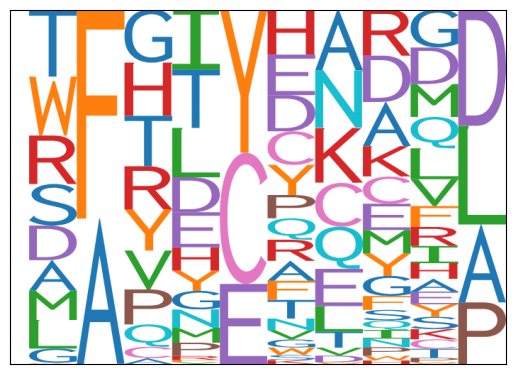

In [50]:
import matplotlib.image as mpimg
image = mpimg.imread(f"{ROOT_dir}/reports/logo/plotly_logo_test.png")
plt.imshow(image)
plt.yticks([])
plt.xticks([])